In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
)
analysis_run = ds.pipeline.open(label="docs_default")
graph = analysis_run["connectivity_map"]
all_features = analysis_run["feature_universe"]

annotations = ds.cells.fetch("clusters", key="I")
source = annotations == "Ductal"
sink = np.isin(annotations, ["Alpha", "Beta", "Delta"])
if not source.any() or not sink.any():
    raise ValueError("Source and sink annotations must both be present")
source_sink_vector = np.zeros(len(annotations), dtype=float)
source_sink_vector[source] = -1.0 / source.sum()
source_sink_vector[sink] = 1.0 / sink.sum()
pseudotime_ref = ds.run_pseudotime_scoring(graph, ss_vec=source_sink_vector)

Downloading bucket files: 52847336 / 52847336 complete

Downloading bytes: 52847336 / 52847336 complete

In [2]:
modules_ref = ds.run_pseudotime_aggregation(
    pseudotime_ref,
    features=all_features,
    n_clusters=15,
    window_size=200,
    chunk_size=100,
)
modules = ds.load_pseudotime_aggregation(modules_ref)
{
    "artifact": modules.ref,
    "pseudotime": modules.pseudotime,
    "feature selection": modules.feature_selection,
    "assigned features": len(modules.feature_indices),
}

{'artifact': ArtifactRef(assay='RNA', kind='pseudotime_aggregation', artifact_id='78deb6296dab...'),
 'pseudotime': ArtifactRef(assay='RNA', kind='pseudotime', artifact_id='4e50844c2f2e...'),
 'feature selection': ArtifactRef(assay='RNA', kind='feature_selection', artifact_id='3d43e87253ac...'),
 'assigned features': 12455}

In [3]:
feature_names = modules.feature_names
module_frame = pd.DataFrame(
    {
        "feature_name": feature_names,
        "module": modules.feature_clusters,
    }
)
module_frame["module"].value_counts().sort_index()

module
1      644
2      126
3      984
4      648
5      469
6      628
7      393
8     1003
9     1335
10    1191
11     295
12    1777
13     740
14    1034
15    1188
Name: count, dtype: int64

In [4]:
examples = (
    module_frame.groupby("module", sort=True)["feature_name"]
    .first()
    .rename("example gene")
)
examples

module
1              Mcm3
2            Stk17b
3            Sbspon
4             Tram2
5            Lactb2
6            Mrpl15
7            Sema4c
8            Adgrb3
9             Cops5
10            Tcf24
11    1700025G04Rik
12           Vcpip1
13             Rev1
14             Eya1
15          Arfgef1
Name: example gene, dtype: str

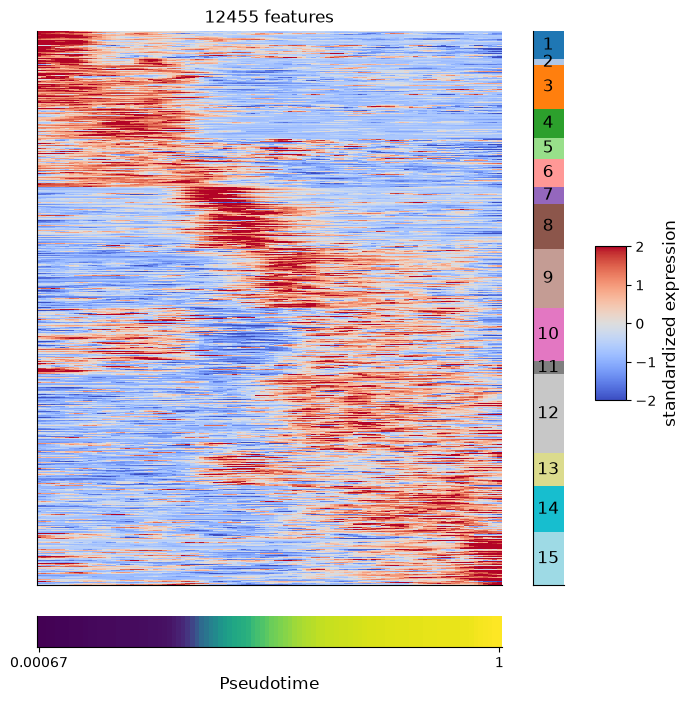

In [5]:
ds.plots.pseudotime_heatmap(
    aggregation=modules_ref,
    figsize=(8, 8),
)

In [6]:
ds.add_grouped_assay(
    modules_ref,
    assay_label="TrajectoryModules",
)
ds.TrajectoryModules

Assay TrajectoryModules with 15 features